In [3]:
!pip uninstall -y scikit-learn imbalanced-learn

Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
Found existing installation: imbalanced-learn 0.11.0
Uninstalling imbalanced-learn-0.11.0:
  Successfully uninstalled imbalanced-learn-0.11.0


In [4]:
!pip install scikit-learn==1.4.2 imbalanced-learn==0.11.0 

  Using cached scikit_learn-1.4.2-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.11.0-py3-none-any.whl.metadata (8.3 kB)
Using cached scikit_learn-1.4.2-cp311-cp311-macosx_12_0_arm64.whl (10.5 MB)
Using cached imbalanced_learn-0.11.0-py3-none-any.whl (235 kB)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
from collections import Counter
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

In [6]:
def load_and_combine_datasets(file_paths):
    datasets = {}
    for name, path in file_paths.items():
        try:
            df = pd.read_csv(path)
            datasets[name] = df
        except Exception as e:
            print(f"Warning: Could not load {name}. Error: {e}")

    combined_data = []
    for name, df in datasets.items():
        text_column = None
        if 'text_combined' in df.columns:
            text_column = 'text_combined'
        elif 'body' in df.columns:
            text_column = 'body'
        
        if text_column and 'label' in df.columns:
            df_subset = df[[text_column, 'label']].copy()
            df_subset.columns = ['text', 'label']
            combined_data.append(df_subset)
    
    combined_df = pd.concat(combined_data, ignore_index=True)
    
    combined_df.dropna(subset=['text'], inplace=True)
    combined_df['text'] = combined_df['text'].astype(str).str.lower().str.strip()
    combined_df = combined_df[combined_df['text'].str.len() > 0]
    
    return combined_df

In [ ]:
file_paths = {
    'SpamAssasin': '/kaggle/input/phishing-email-dataset/SpamAssasin.csv',
    'Nigerian_Fraud': '/kaggle/input/phishing-email-dataset/Nigerian_Fraud.csv',
    'Phishing_Email': '/kaggle/input/phishing-email-dataset/phishing_email.csv',
    'CEAS_08': '/kaggle/input/phishing-email-dataset/CEAS_08.csv',
    'Enron': '/kaggle/input/phishing-email-dataset/Enron.csv',
    'Ling': '/kaggle/input/phishing-email-dataset/Ling.csv',
    'Nazario': '/kaggle/input/phishing-email-dataset/Nazario.csv'
}

In [8]:
print("--- Section 1 & 2: Loading and Preprocessing Data ---")

try:
    combined_df = load_and_combine_datasets(file_paths)
    print(f"Successfully loaded and combined {len(combined_df)} emails.")
    print("Class distribution:")
    print(combined_df['label'].value_counts())
except Exception:
    print("Dataset files not found. Using a placeholder DataFrame for demonstration.")
    data = {'text': ['click here for free money', 'hi team, meeting tomorrow', 'urgent account update', 'see attached report'],
            'label': [1, 0, 1, 0]}
    combined_df = pd.DataFrame(data)

X = combined_df['text']
y = combined_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=95, stratify=y
)
print(f"\nData split into {len(X_train)} training samples and {len(X_test)} testing samples.")


--- Section 1 & 2: Loading and Preprocessing Data ---
Successfully loaded and combined 164966 emails.
Class distribution:
label
1    85776
0    79190
Name: count, dtype: int64

Data split into 131972 training samples and 32994 testing samples.


In [9]:
print("\n--- Section 4: Creating the ML Pipeline ---")

phishing_detection_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=1000,
        stop_words='english',
        ngram_range=(1, 2), 
        lowercase=True
    )),
   ('svm', LinearSVC(
        C=1.0, 
        random_state=95, 
        dual=False, 
        max_iter=1000 
    ))
])
print("Pipeline created successfully with TF-IDF Vectorizer and Linear SVM.")



--- Section 4: Creating the ML Pipeline ---
Pipeline created successfully with TF-IDF Vectorizer and Linear SVM.


In [10]:
print("\n--- Section 3: Training the Model ---")
print("This may take a few minutes...")

phishing_detection_pipeline.fit(X_train, y_train)

print("Model training completed!")



--- Section 3: Training the Model ---
This may take a few minutes...
Model training completed!



--- Section 6: Evaluating Model Performance ---

Test Accuracy: 0.9624

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.97      0.95      0.96     15838
        Spam       0.96      0.97      0.96     17156

    accuracy                           0.96     32994
   macro avg       0.96      0.96      0.96     32994
weighted avg       0.96      0.96      0.96     32994



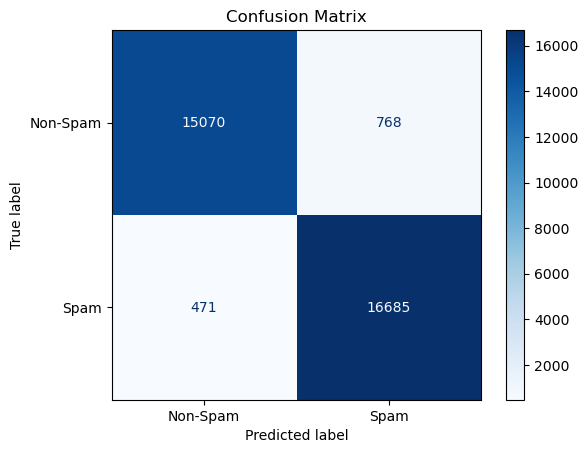


Performing 5-fold cross-validation...
Cross-validation scores: [0.96309907 0.96480394 0.96135485 0.95964992 0.96165795]
Mean CV Accuracy: 0.9621 (+/- 0.0035)


In [11]:
print("\n--- Section 6: Evaluating Model Performance ---")

y_pred = phishing_detection_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Spam', 'Spam']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Spam', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

print("\nPerforming 5-fold cross-validation...")
cv_scores = cross_val_score(phishing_detection_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



--- Section 5: Analyzing Feature Importance for Reporting ---

Top 15 features indicating SPAM:
          feature  coefficient
45           2004     3.638330
259  custom alert     2.900198
145      aug 2008     2.860623
263      daily 10     2.771067
400    guaranteed     2.709920
452    investment     2.639156
46           2005     2.385088
137        assist     2.186693
669         pills     2.177807
238  content type     2.159603
843    statements     2.099921
8            0300     2.006287
753        remove     1.994377
493          life     1.938258
453     investors     1.933064

Top 15 features indicating NON-SPAM:
               feature  coefficient
328              enron    -8.870676
991              wrote    -5.334837
628           opensuse    -5.079368
935  unsubscribe daily    -4.927148
957              vince    -4.243177
368          forwarded    -4.118179
519             louise    -4.101436
530   mailman listinfo    -4.059535
80                 713    -4.017398
467      

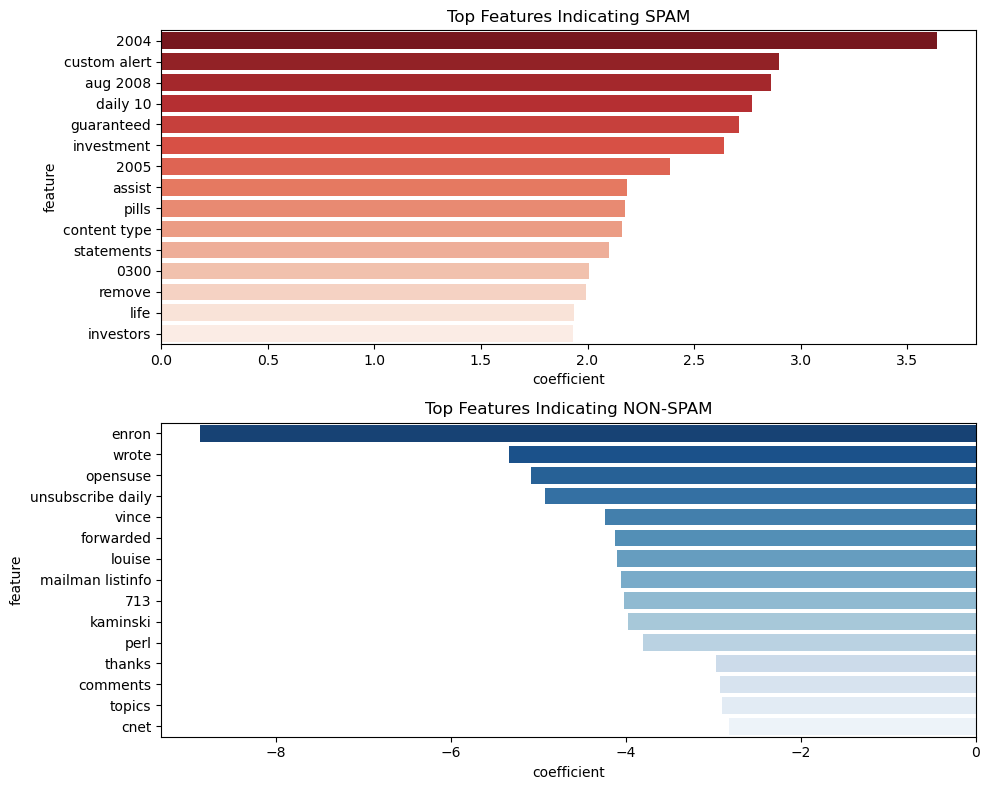

In [12]:
print("\n--- Section 5: Analyzing Feature Importance for Reporting ---")

def analyze_feature_importance(pipeline, top_n=15):
    feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
    svm_coef = pipeline.named_steps['svm'].coef_.flatten()
    
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': svm_coef})
    
    top_positive = coef_df.sort_values(by='coefficient', ascending=False).head(top_n)
    top_negative = coef_df.sort_values(by='coefficient', ascending=True).head(top_n)
    
    print(f"\nTop {top_n} features indicating SPAM:")
    print(top_positive)
    
    print(f"\nTop {top_n} features indicating NON-SPAM:")
    print(top_negative)
    
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    sns.barplot(x='coefficient', y='feature', data=top_positive, palette='Reds_r')
    plt.title('Top Features Indicating SPAM')
    
    plt.subplot(2, 1, 2)
    sns.barplot(x='coefficient', y='feature', data=top_negative, palette='Blues_r')
    plt.title('Top Features Indicating NON-SPAM')
    
    plt.tight_layout()
    plt.show()

analyze_feature_importance(phishing_detection_pipeline)

In [13]:
print("\n--- Section 7: Saving Model for Reproducibility ---")

os.makedirs('model_output', exist_ok=True)
model_path = os.path.join('model_output', 'svm_phishing_detector.pkl')
joblib.dump(phishing_detection_pipeline, model_path)
print(f"Model saved to: {model_path}")

metrics = {
    'accuracy': accuracy,
    'classification_report': classification_report(y_test, y_pred, target_names=['Non-Spam', 'Spam'], output_dict=True),
    'confusion_matrix': cm.tolist(),
    'cross_val_mean_accuracy': cv_scores.mean()
}
metrics_path = os.path.join('model_output', 'model_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to: {metrics_path}")



--- Section 7: Saving Model for Reproducibility ---
Model saved to: model_output/svm_phishing_detector.pkl
Metrics saved to: model_output/model_metrics.json


In [14]:
print("\n--- Testing the trained model with new sample emails ---")
sample_emails = [
    "Congratulations! You have won $1,000,000! Click here to claim your prize.",
    "Hi team, can you please send me the report by EOD? Thanks!",
    "URGENT: Your bank account has been compromised. Verify your details now!",
]

predictions = phishing_detection_pipeline.predict(sample_emails)

for email, pred in zip(sample_emails, predictions):
    print(f"\nEmail: '{email}'")
    print(f"-> Prediction: {'SPAM' if pred == 1 else 'NON-SPAM'}")


--- Testing the trained model with new sample emails ---

Email: 'Congratulations! You have won $1,000,000! Click here to claim your prize.'
-> Prediction: SPAM

Email: 'Hi team, can you please send me the report by EOD? Thanks!'
-> Prediction: NON-SPAM

Email: 'URGENT: Your bank account has been compromised. Verify your details now!'
-> Prediction: SPAM


Deliverable 5 
Evaluating Model

Test Accuracy: 0.9624

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.97      0.95      0.96     15838
        Spam       0.96      0.97      0.96     17156

    accuracy                           0.96     32994
   macro avg       0.96      0.96      0.96     32994
weighted avg       0.96      0.96      0.96     32994



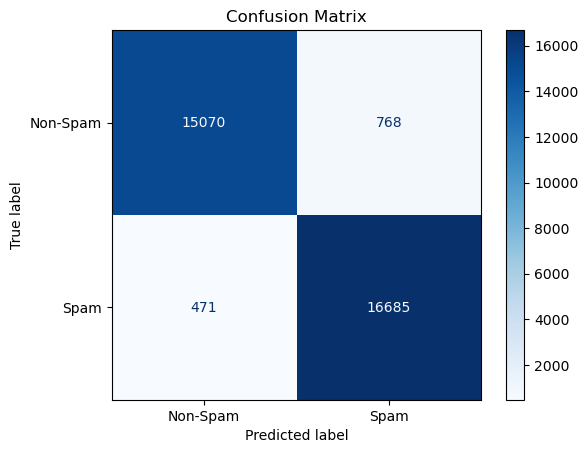

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score, f1_score


y_pred = phishing_detection_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Spam', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Spam', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

ROC Curve & AUC 

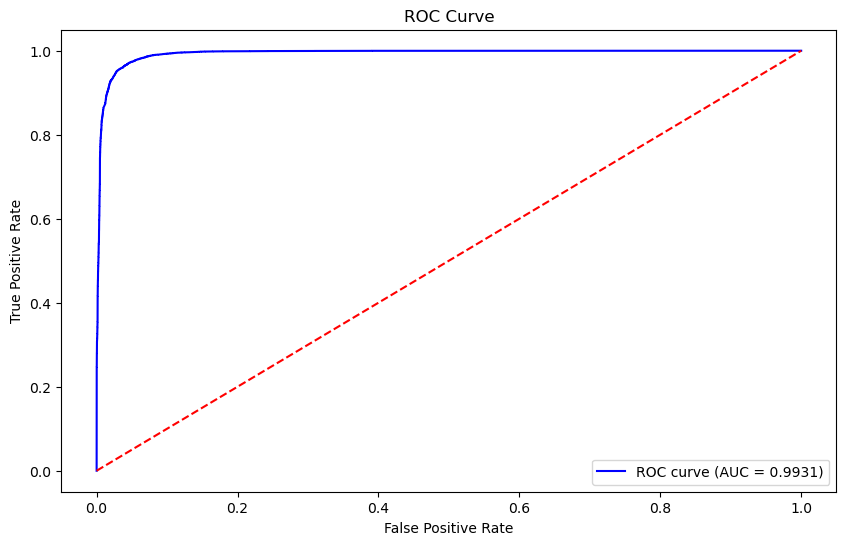

In [ ]:

y_prob = phishing_detection_pipeline.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Residual Plot

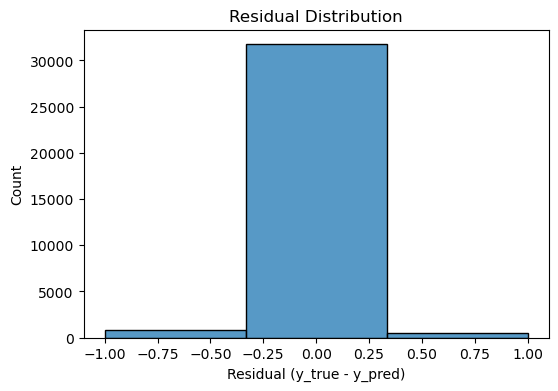

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=3, kde=False)
plt.xlabel('Residual (y_true - y_pred)')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.show()

Performance Table

In [21]:
performance_summary = {
    'Accuracy': accuracy,
    'Precision': precision_score(y_test, y_pred, pos_label=1),
    'Recall': recall_score(y_test, y_pred, pos_label=1),
    'F1-score': f1_score(y_test, y_pred, pos_label=1),
    'ROC AUC': roc_auc
}

perf_df = pd.DataFrame(performance_summary, index=[0])
print("\nPerformance Summary Table:")
print(perf_df)


Performance Summary Table:
   Accuracy  Precision    Recall  F1-score   ROC AUC
0  0.962448   0.955996  0.972546    0.9642  0.993129


Save Updated Metrics

In [19]:
import json
import os

metrics_updated = {
    'accuracy': accuracy,
    'classification_report': classification_report(y_test, y_pred, target_names=['Non-Spam', 'Spam'], output_dict=True),
    'confusion_matrix': cm.tolist(),
    'roc_auc': roc_auc
}

os.makedirs('model_output', exist_ok=True)
metrics_path = os.path.join('model_output', 'model_metrics_deliverable5.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_updated, f, indent=4)
print(f"Updated metrics saved to: {metrics_path}")


Updated metrics saved to: model_output/model_metrics_deliverable5.json
